## Estadistica Aplicada

Secion 7 - 5 Septiembre

Bryan Alejandro Estrada Rodriguez 1844554 

Grupo 42


In [1]:
# librerias basicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
# libreria especializada
from lifelines import ExponentialFitter

In [2]:
!pip install lifelines

In [9]:
recaida = pd.read_csv('ejercicio_expo.csv')
recaida

,Paciente,tiempo,estado
0,1,5,1
1,2,8,1
2,3,12,1
3,4,24,1
4,5,32,1
5,6,17,1
6,7,16,0
7,8,17,0
8,9,19,0
9,10,30,0


In [7]:
exponen = ExponentialFitter().fit(recaida[' tiempo'],recaida[' estado'])

In [12]:
exponen.print_summary()

<lifelines.ExponentialFitter:"Exponential_estimate", fitted with 10 total observations, 4 right-censored observations>
   number of observations = 10
number of events observed = 6
           log-likelihood = -26.41
               hypothesis = lambda_ != 0

---
          coef   se(coef)   coef lower 95%   coef upper 95%
lambda_  30.00      12.25             6.00            54.00

          cmp to    z    p   -log2(p)
lambda_     0.00 2.45 0.01       6.13
---
AIC = 54.81

In [13]:
# a) tasa de riesgo
exponen.hazard_

,Exponential_estimate
5.0,0.033333
8.0,0.033333
11.0,0.033333
14.0,0.033333
17.0,0.033333
20.0,0.033333
23.0,0.033333
26.0,0.033333
29.0,0.033333
32.0,0.033333


(0.0, 0.5)

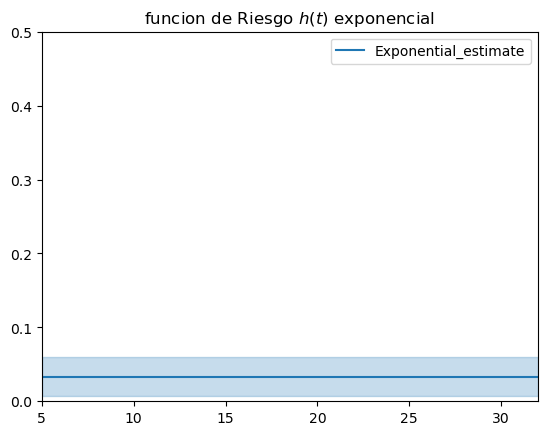

In [17]:
#graficar h(t)
exponen.plot_hazard()
plt.title('funcion de Riesgo $h(t)$ exponencial')
plt.xlim(5,32)
plt.ylim(0,0.5)

In [18]:
# b) la probabilidad de no recaer en 16 meses S(16)
exponen.survival_function_at_times(16)

16    0.586646
Name: Exponential_estimate, dtype: float64

(0.0, 0.5)

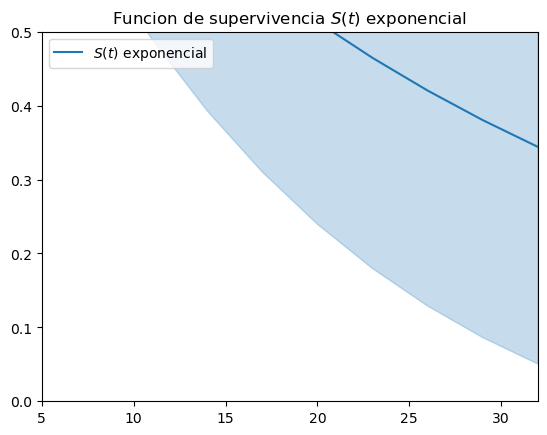

In [44]:
# Grafica e la funcion de supervivencia  
exponen.plot_survival_function(label= '$S(t)$ exponencial')
plt.title('Funcion de supervivencia $S(t)$ exponencial')
plt.xlim(5,32)
plt.ylim(0,0.5)

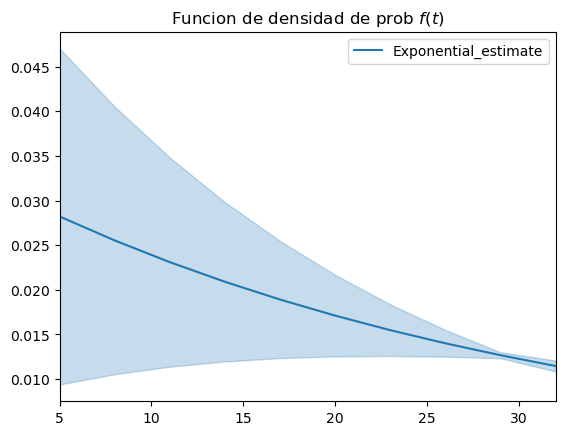

In [25]:
## f(t) funcion de densidad de probabilidad
exponen.plot_density()
plt.title('Funcion de densidad de prob $f(t)$')
plt.xlim(5,32);

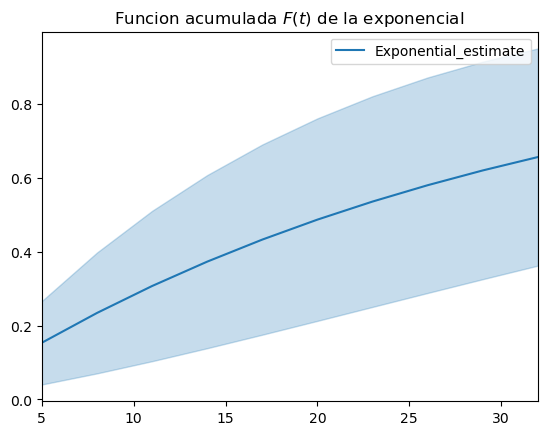

In [24]:
# F(t) acumulada
exponen.plot_cumulative_density()
plt.title('Funcion acumulada $F(t)$ de la exponencial ')
plt.xlim(5,32);

Vamos a suponer que tiempo de supervivencia de los datos se distribuye como una weibull

In [28]:
from lifelines import WeibullFitter

In [30]:
mweibull = WeibullFitter().fit(recaida[' tiempo'],recaida[' estado'])

In [31]:
# parametro GAMMA
mweibull.rho_

1.8867259500116444

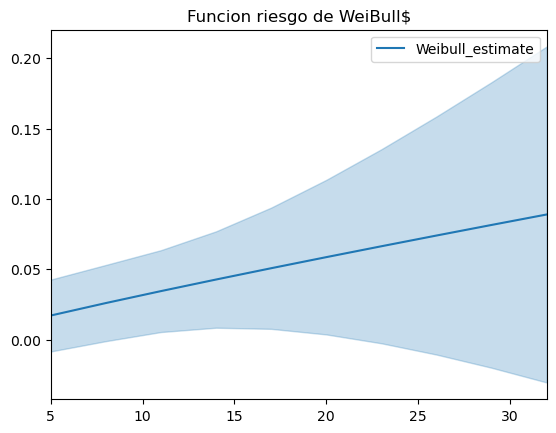

In [32]:
mweibull.plot_hazard()
plt.title('Funcion riesgo de WeiBull$')
plt.xlim(5,32);

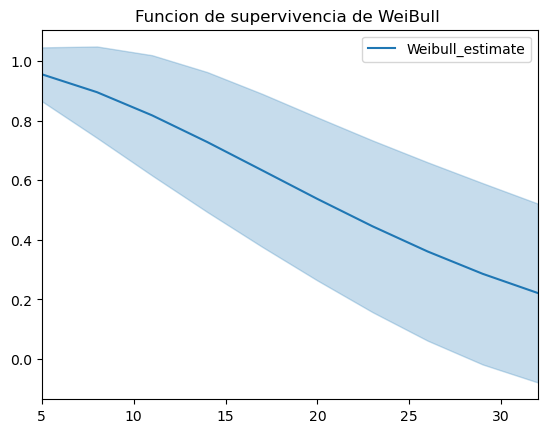

In [43]:
# funciond e supervivencia de la Weibull
mweibull.plot_survival_function()
plt.title('Funcion de supervivencia de WeiBull ')
plt.xlim(5,32);

In [ ]:
# f(t) de la Weibull
mweibull.plot_density()
plt.title('Funcion de densidad de probabilidad de WeiBull ')
plt.xlim(5,32);

Vamos a suponer que tiempo de supervivencia de los datos se distribuye como log-normal 

In [35]:
from lifelines import LogNormalFitter

In [36]:
mlogn = LogNormalFitter().fit(recaida[' tiempo'],recaida[' estado'])

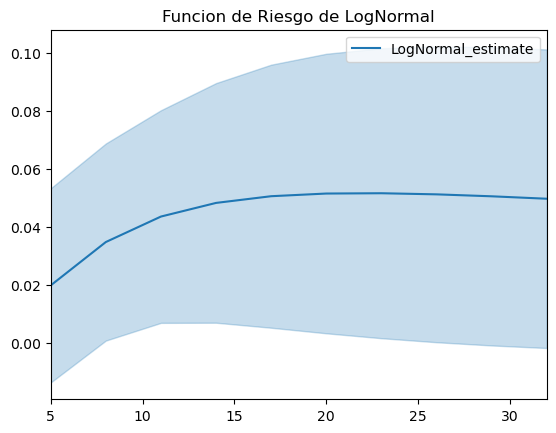

In [38]:
# Riesgo de Log Normal
mlogn.plot_hazard()
plt.title('Funcion de Riesgo de LogNormal')
plt.xlim(5,32);

In [39]:
mlogn.hazard_

,LogNormal_estimate
5.0,0.019961
8.0,0.034916
11.0,0.043704
14.0,0.048408
17.0,0.050720
20.0,0.051641
23.0,0.051744
26.0,0.051361
29.0,0.050690
32.0,0.049850


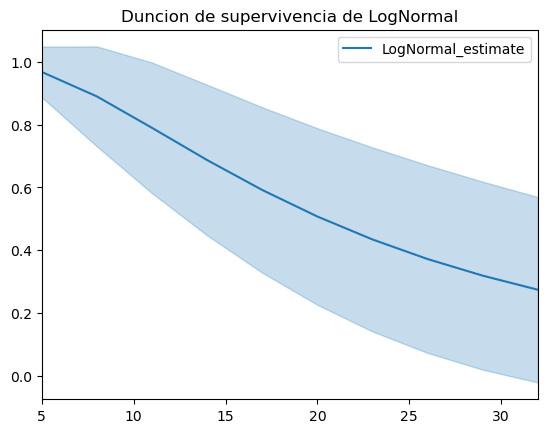

In [41]:
# Funcion de supervivencia log normal
mlogn.plot_survival_function()
plt.title('Duncion de supervivencia de LogNormal')
plt.xlim(5,32);

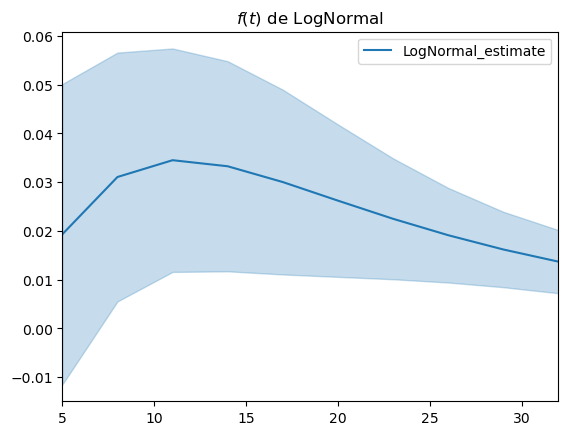

In [42]:
# Funcion de densidad de supervivencia de LogNormal
mlogn.plot_density()
plt.title('$f(t)$ de LogNormal')
plt.xlim(5,32);

¿El tiempo de supervivencia de recaidaes exponencial, weibull o log-normal?

El criterio de Akaike, sirve para elegir el "mejor" modelo. $AIC = -2ln Verosimilitud + 2K $ 
donde K es el numero de parametros del modelo de regresion. El mejor modelo es el que tiene el menor valor de AIC. AIC prefiere modelos simples

In [48]:
print('Expoencial:',exponen.AIC_.round(2),'  Weibull:', mweibull.AIC_.round(2),'  Log.normal', mlogn.AIC_.round(2))

Expoencial: 54.81 ,  Weibull: 54.16   Log.normal 54.51


De acuerdo con el criterio de AIC el "mejor" modelo es Weinbull, el riesgo de recaida es creciente 